# 03d — Top-3 FlexPepDock Deep Refinement (`nstruct = 20`)

## Obiettivo

Questo notebook approfondisce i tre migliori frammenti emersi dal notebook **03c**:

| Fragment ID | Sequenza | Lunghezza |
|---|---|---:|
| F0005 | `GYIGERCQYRDLKWW` | 15 aa |
| F0010 | `IGERCQYRDLK` | 11 aa |
| F0001 | `YIGERCQYRDLKW` | 13 aa |

Per ciascun frammento vengono generate **20 pose FlexPepDock**, per un totale atteso di:

```text
3 frammenti × 20 pose = 60 pose
```

Il notebook:

1. recupera automaticamente gli input preparati dal 03c;
2. verifica sequenze, catene e lunghezze;
3. esegue FlexPepDock separatamente per ogni frammento;
4. mostra l'avanzamento nel notebook;
5. può riprendere un'esecuzione parzialmente completata;
6. raccoglie tutte le pose e tutti gli score;
7. analizza distribuzioni, mediana e migliori score;
8. calcola RMSD, ritenzione dei contatti, contatti degli hotspot e clash;
9. confronta la robustezza dei tre lead;
10. produce un ranking approfondito.

## Posizione nella pipeline

```text
02d → 03c screening nstruct=2 → 03d approfondimento top-3 nstruct=20
```

## Interpretazione

Il protocollo resta un **refinement guidato da una posa vicina a quella nativa**.  
Le 20 pose migliorano il campionamento locale, ma non trasformano il test in docking cieco né dimostrano affinità sperimentale.


## 1. Dipendenze

```bash
pip install pandas numpy matplotlib biopython
```

È richiesta l'installazione Rosetta già utilizzata nel notebook 03c.


In [1]:
from pathlib import Path
from collections import defaultdict
import json
import math
import os
import re
import shutil
import subprocess
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from Bio.PDB import (
        PDBParser,
        PDBIO,
        Superimposer,
        NeighborSearch,
        is_aa,
    )
except ImportError as exc:
    raise ImportError(
        "Biopython non è installato. Eseguire: pip install biopython"
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

print("Ambiente inizializzato correttamente.")

Ambiente inizializzato correttamente.


## 2. Configurazione

Il notebook usa una cartella di output distinta dal 03c, così i risultati preliminari non vengono sovrascritti.

### Ripresa automatica

Con:

```python
SKIP_COMPLETED_FRAGMENTS = True
```

un frammento che possiede già almeno 20 PDB e uno scorefile non viene rieseguito.

Se un frammento è incompleto, la sua cartella viene rinominata come backup prima della nuova esecuzione.


In [2]:
LEAD_FRAGMENT_IDS = ["F0005", "F0010", "F0001"]

EXPECTED_SEQUENCES = {
    "F0005": "GYIGERCQYRDLKWW",
    "F0010": "IGERCQYRDLK",
    "F0001": "YIGERCQYRDLKW",
}

EXPECTED_LENGTHS = {
    "F0005": 15,
    "F0010": 11,
    "F0001": 13,
}

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

CONTACT_CUTOFF_A = 4.5
CLASH_CUTOFF_A = 2.0

ROSETTA_NSTRUCT = 20
RUN_ROSETTA = True
SKIP_COMPLETED_FRAGMENTS = True
BACKUP_INCOMPLETE_OUTPUTS = True

ROSETTA_FLEXPEPDOCK_EXECUTABLE = Path(
    "/Users/robertobruzzese/Downloads/"
    "rosetta.binary.m1.release-408/main/source/build/src/release/"
    "macos/12.7/64/arm/clang/14.0/static/"
    "FlexPepDocking.static.macosclangrelease"
)

ROSETTA_DATABASE = Path(
    "/Users/robertobruzzese/Downloads/"
    "rosetta.binary.m1.release-408/main/database"
)

OUTPUT_DIR = Path("outputs")

SOURCE_03C_DIR = OUTPUT_DIR / "short_peptide_guided_docking_03c"
SOURCE_INPUT_DIR = (
    SOURCE_03C_DIR / "rosetta_flexpepdock" / "inputs"
)
SOURCE_RANKING_CSV = (
    SOURCE_03C_DIR / "guided_docking_final_ranking.csv"
)

DEEP_DIR = OUTPUT_DIR / "top3_flexpepdock_deep_refinement_03d"
INPUT_DIR = DEEP_DIR / "inputs"
ROSETTA_DIR = DEEP_DIR / "rosetta"
ROSETTA_OUTPUT_DIR = ROSETTA_DIR / "outputs"
BEST_POSE_DIR = DEEP_DIR / "best_poses"
TOP_POSES_DIR = DEEP_DIR / "top5_poses"

for directory in [
    DEEP_DIR,
    INPUT_DIR,
    ROSETTA_DIR,
    ROSETTA_OUTPUT_DIR,
    BEST_POSE_DIR,
    TOP_POSES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Lead:", LEAD_FRAGMENT_IDS)
print("Pose per lead:", ROSETTA_NSTRUCT)
print("Pose totali attese:", len(LEAD_FRAGMENT_IDS) * ROSETTA_NSTRUCT)
print("Output:", DEEP_DIR.resolve())

Lead: ['F0005', 'F0010', 'F0001']
Pose per lead: 20
Pose totali attese: 60
Output: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d


## 3. Recupero degli input dal 03c

Il notebook cerca i file:

```text
outputs/short_peptide_guided_docking_03c/
    rosetta_flexpepdock/inputs/F0005.pdb
    rosetta_flexpepdock/inputs/F0010.pdb
    rosetta_flexpepdock/inputs/F0001.pdb
```

Se non li trova, prova a recuperarli dal manifest o dalla cartella `inputs/` del 03c.


In [3]:
def find_source_input(fragment_id):
    candidates = [
        SOURCE_INPUT_DIR / f"{fragment_id}.pdb",
        SOURCE_03C_DIR / "inputs" / f"{fragment_id}_native_complex.pdb",
        SOURCE_03C_DIR / "inputs" / f"{fragment_id}.pdb",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    matches = sorted(SOURCE_03C_DIR.rglob(f"{fragment_id}*.pdb"))
    matches = [
        path for path in matches
        if "best_poses" not in str(path)
        and "outputs" not in str(path.parent)
    ]

    if matches:
        return matches[0].resolve()

    raise FileNotFoundError(
        f"Input nativo non trovato per {fragment_id}. "
        "Eseguire prima il notebook 03c."
    )


source_inputs = {
    fragment_id: find_source_input(fragment_id)
    for fragment_id in LEAD_FRAGMENT_IDS
}

for fragment_id, path in source_inputs.items():
    print(fragment_id, "→", path)

F0005 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0005.pdb
F0010 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb
F0001 → /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0001.pdb


## 4. Validazione di catene e sequenze


In [4]:
parser = PDBParser(QUIET=True)

AA3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}


def standard_residues(chain):
    return [
        residue for residue in chain
        if is_aa(residue, standard=True)
    ]


def sequence_from_chain(chain):
    return "".join(
        AA3_TO_1.get(residue.get_resname().upper(), "X")
        for residue in standard_residues(chain)
    )


validation_rows = []
input_paths = {}

for fragment_id in LEAD_FRAGMENT_IDS:
    source = source_inputs[fragment_id]
    structure = parser.get_structure(fragment_id, str(source))
    model = next(structure.get_models())
    chain_ids = [chain.id for chain in model]

    if RECEPTOR_CHAIN not in chain_ids or PEPTIDE_CHAIN not in chain_ids:
        raise ValueError(
            f"{fragment_id}: servono le catene B e D; trovate {chain_ids}."
        )

    observed_sequence = sequence_from_chain(model[PEPTIDE_CHAIN])
    observed_length = len(standard_residues(model[PEPTIDE_CHAIN]))

    expected_sequence = EXPECTED_SEQUENCES[fragment_id]
    expected_length = EXPECTED_LENGTHS[fragment_id]

    if observed_sequence != expected_sequence:
        raise ValueError(
            f"{fragment_id}: sequenza osservata {observed_sequence}, "
            f"attesa {expected_sequence}."
        )

    if observed_length != expected_length:
        raise ValueError(
            f"{fragment_id}: lunghezza osservata {observed_length}, "
            f"attesa {expected_length}."
        )

    target = INPUT_DIR / f"{fragment_id}.pdb"
    shutil.copy2(source, target)
    input_paths[fragment_id] = target

    validation_rows.append({
        "fragment_id": fragment_id,
        "source_pdb": str(source),
        "deep_input_pdb": str(target),
        "chains": ",".join(chain_ids),
        "observed_sequence": observed_sequence,
        "expected_sequence": expected_sequence,
        "observed_length": observed_length,
        "expected_length": expected_length,
        "sequence_match": observed_sequence == expected_sequence,
        "length_match": observed_length == expected_length,
    })

input_validation = pd.DataFrame(validation_rows)
display(input_validation)

print("Tutti gli input sono validi.")

,fragment_id,source_pdb,deep_input_pdb,chains,observed_sequence,expected_sequence,observed_length,expected_length,sequence_match,length_match
0,F0005,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0005.pdb,outputs/top3_flexpepdock_deep_refinement_03d/inputs/F0005.pdb,"B,D",GYIGERCQYRDLKWW,GYIGERCQYRDLKWW,15,15,True,True
1,F0010,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb,outputs/top3_flexpepdock_deep_refinement_03d/inputs/F0010.pdb,"B,D",IGERCQYRDLK,IGERCQYRDLK,11,11,True,True
2,F0001,/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0001.pdb,outputs/top3_flexpepdock_deep_refinement_03d/inputs/F0001.pdb,"B,D",YIGERCQYRDLKW,YIGERCQYRDLKW,13,13,True,True


Tutti gli input sono validi.


## 5. Individuazione di Rosetta


In [5]:
def resolve_executable(configured_path, names):
    configured = Path(configured_path).expanduser()

    if configured.exists() and os.access(configured, os.X_OK):
        return str(configured.resolve())

    for name in names:
        found = shutil.which(name)
        if found:
            return str(Path(found).resolve())

    return None


rosetta_bin = resolve_executable(
    ROSETTA_FLEXPEPDOCK_EXECUTABLE,
    [
        "FlexPepDocking.static.macosclangrelease",
        "FlexPepDocking.default.macosclangrelease",
        "FlexPepDocking.static.linuxgccrelease",
        "FlexPepDocking.default.linuxgccrelease",
    ],
)

rosetta_db = Path(ROSETTA_DATABASE).expanduser()

print("Detected Rosetta:", rosetta_bin)
print("Rosetta database:", rosetta_db)
print("RUN_ROSETTA:", RUN_ROSETTA)
print("ROSETTA_NSTRUCT:", ROSETTA_NSTRUCT)

if RUN_ROSETTA:
    if rosetta_bin is None:
        raise FileNotFoundError(
            "FlexPepDocking non trovato. Verificare il percorso configurato."
        )

    if not rosetta_db.exists():
        raise FileNotFoundError(
            "Database Rosetta non trovato. Verificare ROSETTA_DATABASE."
        )

Detected Rosetta: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/source/build/src/release/macos/12.7/64/arm/clang/14.0/static/FlexPepDocking.static.macosclangrelease
Rosetta database: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/database
RUN_ROSETTA: True
ROSETTA_NSTRUCT: 20


## 6. Stato iniziale delle cartelle di output


In [6]:
def output_status(fragment_id):
    output_dir = ROSETTA_OUTPUT_DIR / fragment_id
    pdb_files = sorted(output_dir.glob("*.pdb"))
    score_files = sorted(output_dir.glob("*.sc"))
    log_files = sorted(output_dir.glob("*.log"))

    complete = (
        len(pdb_files) >= ROSETTA_NSTRUCT
        and len(score_files) >= 1
    )

    return {
        "fragment_id": fragment_id,
        "output_dir": str(output_dir),
        "n_pdb_poses": len(pdb_files),
        "n_scorefiles": len(score_files),
        "n_logs": len(log_files),
        "expected_poses": ROSETTA_NSTRUCT,
        "complete": complete,
    }


initial_status = pd.DataFrame(
    [output_status(fragment_id) for fragment_id in LEAD_FRAGMENT_IDS]
)
display(initial_status)

,fragment_id,output_dir,n_pdb_poses,n_scorefiles,n_logs,expected_poses,complete
0,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005,0,0,0,20,False
1,F0010,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0010,0,0,0,20,False
2,F0001,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001,0,0,0,20,False


## 7. Esecuzione FlexPepDock con avanzamento visibile

A differenza del 03c, ogni frammento viene avviato separatamente dal Python notebook.

Durante l'esecuzione il notebook mostra:

- frammento corrente;
- comando;
- tempo impiegato;
- numero di pose prodotte;
- posizione del log.

Rosetta continua a scrivere i dettagli nel file `.log`.


In [7]:
execution_rows = []

if RUN_ROSETTA:
    for index, fragment_id in enumerate(LEAD_FRAGMENT_IDS, start=1):
        input_path = input_paths[fragment_id].resolve()
        output_dir = ROSETTA_OUTPUT_DIR / fragment_id
        output_dir.mkdir(parents=True, exist_ok=True)

        before = output_status(fragment_id)

        if SKIP_COMPLETED_FRAGMENTS and before["complete"]:
            print(
                f"[{index}/{len(LEAD_FRAGMENT_IDS)}] "
                f"{fragment_id}: già completo, salto."
            )

            execution_rows.append({
                "fragment_id": fragment_id,
                "status": "SKIPPED_ALREADY_COMPLETE",
                "returncode": 0,
                "elapsed_seconds": 0.0,
                "n_pdb_poses_after": before["n_pdb_poses"],
                "log_file": str(
                    output_dir / f"{fragment_id}_n20.log"
                ),
            })
            continue

        existing_files = list(output_dir.iterdir())

        if existing_files and BACKUP_INCOMPLETE_OUTPUTS:
            timestamp = time.strftime("%Y%m%d_%H%M%S")
            backup_dir = (
                ROSETTA_OUTPUT_DIR
                / f"{fragment_id}_incomplete_backup_{timestamp}"
            )
            output_dir.rename(backup_dir)
            output_dir.mkdir(parents=True, exist_ok=True)

            print(
                f"{fragment_id}: output incompleto spostato in "
                f"{backup_dir.name}"
            )

        scorefile_name = f"{fragment_id}_n20_refinement.sc"
        log_path = output_dir / f"{fragment_id}_n20.log"

        command = [
            rosetta_bin,
            "-database", str(rosetta_db.resolve()),
            "-s", str(input_path),
            "-pep_refine",
            "-ex1",
            "-ex2aro",
            "-use_input_sc",
            "-nstruct", str(ROSETTA_NSTRUCT),
            "-out:path:pdb", str(output_dir.resolve()),
            "-out:path:score", str(output_dir.resolve()),
            "-out:file:scorefile", scorefile_name,
            "-overwrite",
        ]

        print()
        print("=" * 80)
        print(
            f"[{index}/{len(LEAD_FRAGMENT_IDS)}] "
            f"Avvio {fragment_id} — "
            f"{EXPECTED_LENGTHS[fragment_id]} aa — "
            f"{ROSETTA_NSTRUCT} pose"
        )
        print("Input:", input_path)
        print("Output:", output_dir.resolve())
        print("Log:", log_path.resolve())
        print("=" * 80)

        start_time = time.time()

        with log_path.open("w", encoding="utf-8") as log_handle:
            process = subprocess.Popen(
                command,
                stdout=log_handle,
                stderr=subprocess.STDOUT,
                text=True,
            )

            while process.poll() is None:
                elapsed = time.time() - start_time
                n_poses_now = len(list(output_dir.glob("*.pdb")))

                print(
                    f"  {fragment_id}: "
                    f"{n_poses_now}/{ROSETTA_NSTRUCT} PDB presenti — "
                    f"{elapsed/60:.1f} min",
                    end="\r",
                    flush=True,
                )

                time.sleep(15)

            returncode = process.wait()

        elapsed = time.time() - start_time
        after = output_status(fragment_id)

        print(
            f"  {fragment_id}: "
            f"{after['n_pdb_poses']}/{ROSETTA_NSTRUCT} pose — "
            f"terminato in {elapsed/60:.1f} min"
        )

        status = (
            "COMPLETED"
            if returncode == 0 and after["complete"]
            else "FAILED_OR_INCOMPLETE"
        )

        execution_rows.append({
            "fragment_id": fragment_id,
            "status": status,
            "returncode": int(returncode),
            "elapsed_seconds": float(elapsed),
            "n_pdb_poses_after": after["n_pdb_poses"],
            "n_scorefiles_after": after["n_scorefiles"],
            "log_file": str(log_path),
        })

        if returncode != 0:
            tail = log_path.read_text(
                encoding="utf-8",
                errors="ignore",
            ).splitlines()[-30:]

            raise RuntimeError(
                f"{fragment_id}: Rosetta terminato con codice "
                f"{returncode}.\nUltime righe del log:\n"
                + "\n".join(tail)
            )

        if not after["complete"]:
            raise RuntimeError(
                f"{fragment_id}: Rosetta è terminato ma gli output "
                f"sono incompleti ({after['n_pdb_poses']} PDB)."
            )

    print()
    print("Tutti i refinement richiesti sono stati completati.")
else:
    print("RUN_ROSETTA=False: nessuna esecuzione avviata.")

execution_status = pd.DataFrame(execution_rows)
display(execution_status)


[1/3] Avvio F0005 — 15 aa — 20 pose
Input: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/inputs/F0005.pdb
Output: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005
Log: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20.log
  F0005: 20/20 pose — terminato in 24.5 min

[2/3] Avvio F0010 — 11 aa — 20 pose
Input: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/inputs/F0010.pdb
Output: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0010
Log: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0010/F0010_n20.log
  F0010: 20/20 pose — terminato in 27.0 min

[3/3] Avvio F0001 — 13 aa — 20 pose
Input: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/inputs/F0001.pdb
Output: /Users/rober

,fragment_id,status,returncode,elapsed_seconds,n_pdb_poses_after,n_scorefiles_after,log_file
0,F0005,COMPLETED,0,1470.717162,20,1,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20.log
1,F0010,COMPLETED,0,1620.894719,20,1,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0010/F0010_n20.log
2,F0001,COMPLETED,0,1455.791159,20,1,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_n20.log


## 8. Verifica finale degli output

Il risultato atteso è:

```text
20 PDB × 3 frammenti = 60 PDB
```


In [8]:
final_status = pd.DataFrame(
    [output_status(fragment_id) for fragment_id in LEAD_FRAGMENT_IDS]
)

display(final_status)

total_pose_count = int(final_status["n_pdb_poses"].sum())

print("Pose PDB totali:", total_pose_count)
print("Pose totali attese:", len(LEAD_FRAGMENT_IDS) * ROSETTA_NSTRUCT)

if RUN_ROSETTA and not final_status["complete"].all():
    raise AssertionError(
        "Almeno un frammento non possiede tutti gli output attesi."
    )

,fragment_id,output_dir,n_pdb_poses,n_scorefiles,n_logs,expected_poses,complete
0,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005,20,1,1,20,True
1,F0010,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0010,20,1,1,20,True
2,F0001,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001,20,1,1,20,True


Pose PDB totali: 60
Pose totali attese: 60


## 9. Parsing degli score Rosetta


In [9]:
def parse_rosetta_scorefile(path):
    score_lines = [
        line.strip()
        for line in Path(path).read_text(
            encoding="utf-8",
            errors="ignore",
        ).splitlines()
        if line.startswith("SCORE:")
    ]

    if len(score_lines) < 2:
        return pd.DataFrame()

    header = score_lines[0].split()[1:]
    records = []

    for line in score_lines[1:]:
        values = line.split()[1:]

        if len(values) == len(header):
            records.append(dict(zip(header, values)))

    dataframe = pd.DataFrame(records)

    for column in dataframe.columns:
        if column != "description":
            dataframe[column] = pd.to_numeric(
                dataframe[column],
                errors="coerce",
            )

    return dataframe


score_frames = []

for fragment_id in LEAD_FRAGMENT_IDS:
    output_dir = ROSETTA_OUTPUT_DIR / fragment_id
    score_files = sorted(output_dir.glob("*.sc"))

    for score_file in score_files:
        dataframe = parse_rosetta_scorefile(score_file)

        if dataframe.empty:
            continue

        dataframe.insert(0, "fragment_id", fragment_id)
        dataframe.insert(1, "scorefile", str(score_file))
        score_frames.append(dataframe)

all_scores = (
    pd.concat(score_frames, ignore_index=True)
    if score_frames
    else pd.DataFrame()
)

if all_scores.empty:
    raise ValueError("Nessuno score Rosetta disponibile.")

print("Pose con score:", len(all_scores))
print("Colonne:", list(all_scores.columns))
display(all_scores.head(10))

Pose con score: 60
Colonne: ['fragment_id', 'scorefile', 'total_score', 'I_bsa', 'I_hb', 'I_pack', 'I_sc', 'I_unsat', 'dslf_fa13', 'fa_atr', 'fa_dun', 'fa_elec', 'fa_intra_rep', 'fa_intra_sol_xover4', 'fa_rep', 'fa_sol', 'hbond_bb_sc', 'hbond_lr_bb', 'hbond_sc', 'hbond_sr_bb', 'lk_ball_wtd', 'omega', 'p_aa_pp', 'pep_sc', 'pep_sc_noref', 'pro_close', 'rama_prepro', 'ref', 'reweighted_sc', 'rmsALL', 'rmsALL_CAPRI_if', 'rmsALL_allIF', 'rmsALL_if', 'rmsBB', 'rmsBB_CAPRI_if', 'rmsBB_allIF', 'rmsBB_if', 'rmsCA', 'rmsCA_if', 'rmsSC_CAPRI_if', 'rmsSC_allIF', 'startRMSall', 'startRMSallif', 'startRMSbb', 'startRMSca', 'yhh_planarity', 'description']


,fragment_id,scorefile,total_score,I_bsa,I_hb,I_pack,I_sc,I_unsat,dslf_fa13,fa_atr,fa_dun,fa_elec,fa_intra_rep,fa_intra_sol_xover4,fa_rep,fa_sol,hbond_bb_sc,hbond_lr_bb,hbond_sc,hbond_sr_bb,lk_ball_wtd,omega,p_aa_pp,pep_sc,pep_sc_noref,pro_close,rama_prepro,ref,reweighted_sc,rmsALL,rmsALL_CAPRI_if,rmsALL_allIF,rmsALL_if,rmsBB,rmsBB_CAPRI_if,rmsBB_allIF,rmsBB_if,rmsCA,rmsCA_if,rmsSC_CAPRI_if,rmsSC_allIF,startRMSall,startRMSallif,startRMSbb,startRMSca,yhh_planarity,description
0,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,112.535,1774.270,9.0,-0.021,-51.722,10.0,19.909,-3331.350,1089.947,-646.086,7.085,127.435,738.233,2056.533,-90.188,-117.967,-49.369,-60.597,-91.259,30.591,-85.972,-7.875,-15.153,17.463,257.482,239.419,52.938,2.895,1.904,2.001,3.081,0.711,0.432,0.441,0.767,0.725,0.797,2.410,2.509,0.0,0.0,0.0,0.0,1.227,F0005_0001
1,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,85.538,1907.619,9.0,-0.011,-55.271,10.0,19.908,-3333.154,1087.676,-653.061,7.109,126.901,728.270,2056.284,-85.859,-117.761,-46.124,-60.761,-92.260,29.931,-85.871,-21.259,-28.536,15.151,248.588,239.419,9.008,1.594,1.273,1.222,1.669,0.735,0.426,0.434,0.771,0.763,0.804,1.643,1.552,0.0,0.0,0.0,0.0,1.152,F0005_0002
2,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,132.968,1914.971,7.0,0.014,-49.237,5.0,19.914,-3333.502,1103.667,-650.571,7.096,126.306,749.751,2064.007,-85.737,-117.671,-48.334,-62.183,-91.692,30.380,-85.573,-13.010,-20.288,17.447,248.956,239.419,70.721,2.155,1.451,1.400,2.198,1.105,0.580,0.585,1.127,1.135,1.126,1.840,1.743,0.0,0.0,0.0,0.0,1.287,F0005_0003
3,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,119.328,1883.805,10.0,0.005,-52.154,10.0,19.905,-3331.307,1096.166,-646.828,7.061,126.047,740.825,2062.673,-87.492,-117.871,-47.810,-60.507,-92.731,30.766,-85.841,-16.453,-23.731,17.509,247.899,239.419,50.721,2.517,1.760,1.840,2.674,0.891,0.517,0.527,0.963,0.906,0.988,2.253,2.318,0.0,0.0,0.0,0.0,1.446,F0005_0004
4,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,164.946,1821.064,4.0,-0.031,-38.534,16.0,20.144,-3325.588,1102.477,-630.295,7.239,127.249,744.496,2055.919,-74.087,-118.320,-43.437,-61.848,-89.292,31.675,-86.008,-5.759,-13.037,13.065,251.390,239.419,120.653,2.952,1.928,2.008,3.049,1.575,0.822,0.840,1.522,1.634,1.563,2.371,2.462,0.0,0.0,0.0,0.0,0.748,F0005_0005
5,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,115.744,1848.906,9.0,-0.006,-53.300,4.0,19.951,-3334.224,1098.178,-644.854,7.120,127.597,736.931,2059.970,-84.310,-118.082,-47.427,-62.394,-92.974,29.808,-85.732,-18.799,-26.076,17.741,247.681,239.419,43.645,2.558,1.778,1.763,2.717,0.799,0.458,0.460,0.847,0.827,0.854,2.263,2.213,0.0,0.0,0.0,0.0,1.345,F0005_0006
6,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,113.507,1832.340,6.0,0.007,-45.246,8.0,21.730,-3338.233,1095.601,-645.316,7.154,127.290,731.761,2062.196,-87.257,-117.535,-44.466,-60.963,-92.014,31.330,-85.612,-2.742,-10.020,17.375,249.676,239.419,65.519,3.535,2.345,2.341,3.759,1.367,0.762,0.789,1.435,1.437,1.496,2.987,2.944,0.0,0.0,0.0,0.0,1.371,F0005_0007
7,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,102.397,1832.889,11.0,-0.010,-54.896,4.0,19.930,-3343.705,1097.659,-653.733,7.105,127.814,733.240,2073.853,-87.658,-118.771,-49.693,-61.423,-92.047,31.180,-85.604,-17.325,-24.602,15.222,248.067,239.419,30.176,2.783,1.887,1.874,2.957,0.868,0.504,0.504,0.919,0.884,0.914,2.368,2.316,0.0,0.0,0.0,0.0,1.543,F0005_0008
8,F0005,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_n20_refinement.sc,146.004,1771.633,6.0,-0.015,-45.795,6.0,22.466,-3336.747,1109.240,-646.513,7.063,127.414,755.210,2060.763,-84.317,-117.940,-44

## 10. Scelta della metrica principale

Per FlexPepDock viene preferito:

1. `reweighted_sc`;
2. `I_sc`;
3. `total_score`;
4. `score`.

Il valore più basso è considerato migliore.


In [10]:
PRIMARY_SCORE_COLUMN = next(
    (
        column
        for column in [
            "reweighted_sc",
            "I_sc",
            "total_score",
            "score",
        ]
        if column in all_scores.columns
    ),
    None,
)

if PRIMARY_SCORE_COLUMN is None:
    raise ValueError(
        "Nessuna colonna utilizzabile per il ranking Rosetta."
    )

print("Metrica principale:", PRIMARY_SCORE_COLUMN)

Metrica principale: reweighted_sc


## 11. Statistiche delle 20 pose per frammento

Per evitare di basarsi soltanto sulla singola posa migliore, vengono calcolati:

- minimo;
- media;
- mediana;
- deviazione standard;
- primo quartile;
- media delle migliori 5 pose;
- differenza tra la migliore e la mediana;
- numero effettivo di pose.


In [11]:
def mean_best_n(series, n=5):
    valid = pd.to_numeric(series, errors="coerce").dropna()
    return float(valid.nsmallest(min(n, len(valid))).mean())


score_summary = (
    all_scores
    .groupby("fragment_id", as_index=False)
    .agg(
        n_scored_poses=(PRIMARY_SCORE_COLUMN, "count"),
        score_best=(PRIMARY_SCORE_COLUMN, "min"),
        score_mean=(PRIMARY_SCORE_COLUMN, "mean"),
        score_median=(PRIMARY_SCORE_COLUMN, "median"),
        score_std=(PRIMARY_SCORE_COLUMN, "std"),
        score_q25=(PRIMARY_SCORE_COLUMN, lambda x: x.quantile(0.25)),
        score_q75=(PRIMARY_SCORE_COLUMN, lambda x: x.quantile(0.75)),
        score_top5_mean=(PRIMARY_SCORE_COLUMN, mean_best_n),
    )
)

score_summary["best_minus_median"] = (
    score_summary["score_best"]
    - score_summary["score_median"]
)

score_summary["score_I_sc_best"] = np.nan
score_summary["score_I_sc_median"] = np.nan

if "I_sc" in all_scores.columns:
    i_sc_summary = (
        all_scores
        .groupby("fragment_id", as_index=False)
        .agg(
            score_I_sc_best=("I_sc", "min"),
            score_I_sc_median=("I_sc", "median"),
        )
    )

    score_summary = (
        score_summary
        .drop(columns=["score_I_sc_best", "score_I_sc_median"])
        .merge(i_sc_summary, on="fragment_id", how="left")
    )

display(
    score_summary.sort_values("score_top5_mean")
)

,fragment_id,n_scored_poses,score_best,score_mean,score_median,score_std,score_q25,score_q75,score_top5_mean,best_minus_median,score_I_sc_best,score_I_sc_median
2,F0010,20,11.635,57.08765,54.405,28.673296,34.64575,77.45625,22.5024,-42.770,-55.899,-48.4865
1,F0005,20,9.008,58.86325,57.206,28.861265,38.18025,70.78700,25.7108,-48.198,-56.477,-51.2960
0,F0001,20,22.348,62.61875,62.120,26.669790,41.67075,77.56725,31.4060,-39.772,-54.594,-48.7180


## 12. Visualizzazione delle distribuzioni degli score


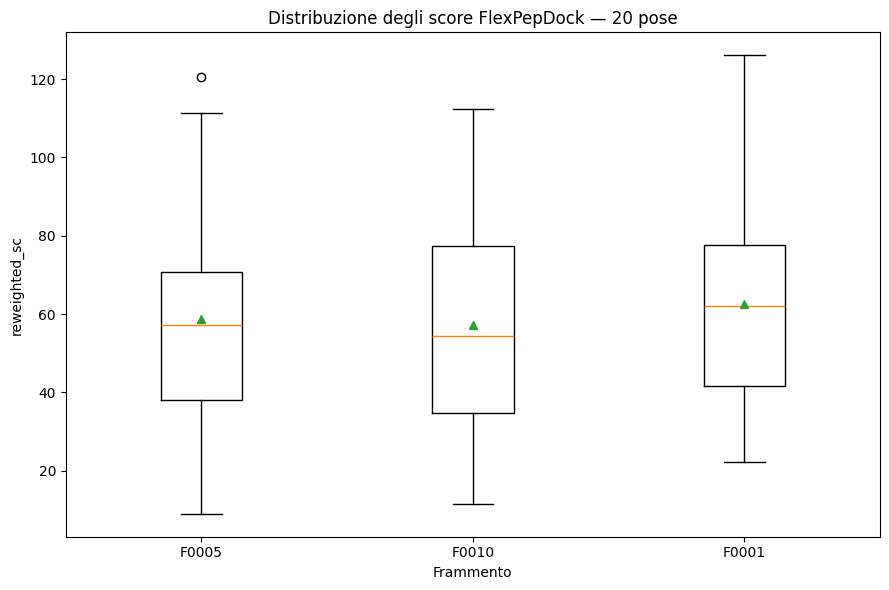

In [13]:
plot_data = [
    all_scores.loc[
        all_scores["fragment_id"] == fragment_id,
        PRIMARY_SCORE_COLUMN,
    ].dropna().values
    for fragment_id in LEAD_FRAGMENT_IDS
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    plot_data,
    labels=LEAD_FRAGMENT_IDS,
    showmeans=True,
)

plt.ylabel(PRIMARY_SCORE_COLUMN)
plt.xlabel("Frammento")
plt.title("Distribuzione degli score FlexPepDock — 20 pose")
plt.tight_layout()

plt.savefig(
    DEEP_DIR / "n20_score_distributions_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

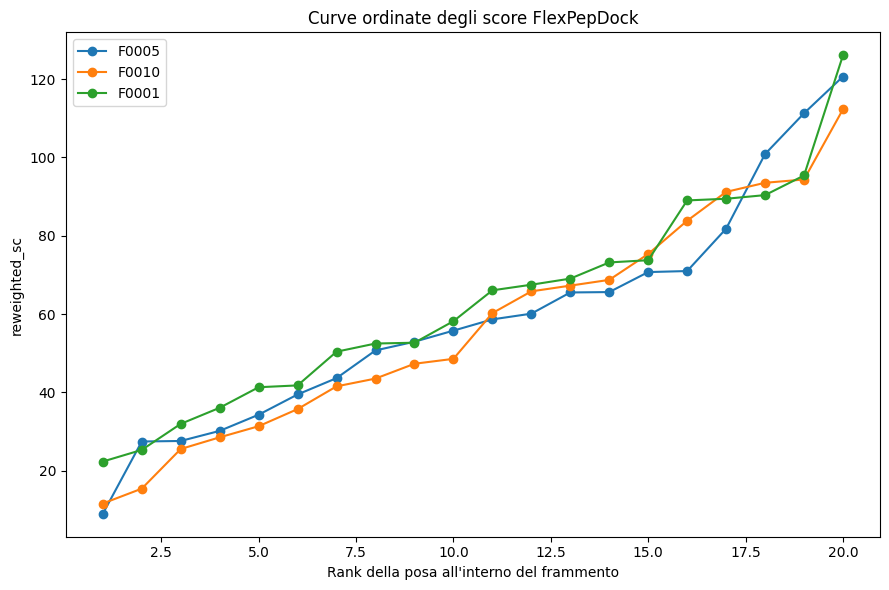

In [14]:
plt.figure(figsize=(9, 6))

for fragment_id in LEAD_FRAGMENT_IDS:
    values = (
        all_scores.loc[
            all_scores["fragment_id"] == fragment_id,
            PRIMARY_SCORE_COLUMN,
        ]
        .dropna()
        .sort_values()
        .reset_index(drop=True)
    )

    plt.plot(
        np.arange(1, len(values) + 1),
        values,
        marker="o",
        label=fragment_id,
    )

plt.xlabel("Rank della posa all'interno del frammento")
plt.ylabel(PRIMARY_SCORE_COLUMN)
plt.title("Curve ordinate degli score FlexPepDock")
plt.legend()
plt.tight_layout()
plt.savefig(
    DEEP_DIR / "n20_ranked_score_curves.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 13. Selezione delle migliori 5 pose per frammento


In [15]:
top_pose_rows = []

for fragment_id, group in all_scores.groupby("fragment_id"):
    group = (
        group
        .dropna(subset=[PRIMARY_SCORE_COLUMN])
        .sort_values(PRIMARY_SCORE_COLUMN)
        .head(5)
        .copy()
    )

    for local_rank, (_, row) in enumerate(
        group.iterrows(),
        start=1,
    ):
        description = str(row["description"])
        pose_path = (
            ROSETTA_OUTPUT_DIR
            / fragment_id
            / f"{description}.pdb"
        )

        record = row.to_dict()
        record["local_pose_rank"] = local_rank
        record["pose_pdb"] = (
            str(pose_path) if pose_path.exists() else ""
        )
        top_pose_rows.append(record)

top5_scores = pd.DataFrame(top_pose_rows)

missing_pose_files = top5_scores[
    top5_scores["pose_pdb"] == ""
]

if not missing_pose_files.empty:
    display(missing_pose_files)
    raise FileNotFoundError(
        "Alcuni PDB delle migliori pose non sono stati trovati."
    )

display(
    top5_scores[
        [
            column
            for column in [
                "fragment_id",
                "local_pose_rank",
                PRIMARY_SCORE_COLUMN,
                "I_sc",
                "total_score",
                "description",
                "pose_pdb",
            ]
            if column in top5_scores.columns
        ]
    ]
)

,fragment_id,local_pose_rank,reweighted_sc,I_sc,total_score,description,pose_pdb
0,F0001,1,22.348,-54.449,92.473,F0001_0001,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0001.pdb
1,F0001,2,25.318,-54.014,96.556,F0001_0006,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0006.pdb
2,F0001,3,31.968,-42.970,90.772,F0001_0020,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0020.pdb
3,F0001,4,36.074,-52.540,107.432,F0001_0015,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0015.pdb
4,F0001,5,41.322,-53.823,114.267,F0001_0007,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0007.pdb
5,F0005,1,9.008,-55.271,85.538,F0005_0002,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0002.pdb
6,F0005,2,27.464,-56.100,107.936,F0005_0015,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0015.pdb
7,F0005,3,27.601,-52.207,97.101,F0005_0014,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0014.pdb
8,F0005,4,30.176,-54.896,102.397,F0005_0008,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0008.pdb
9,F0005,5,34.305,-56.477,112.914,F0005_0011,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0011.pdb


## 14. Funzioni per RMSD, contatti e clash


In [16]:
def heavy_atoms(residues):
    atoms = []

    for residue in residues:
        for atom in residue.get_atoms():
            element = (atom.element or "").strip().upper()

            if element != "H":
                atoms.append(atom)

    return atoms


def residue_key(residue, chain_id):
    _, resseq, icode = residue.id
    return (
        chain_id,
        int(resseq),
        str(icode).strip(),
    )


def ca_atoms_by_residue(chain):
    atoms = {}

    for residue in standard_residues(chain):
        if "CA" not in residue:
            continue

        key = (
            int(residue.id[1]),
            str(residue.id[2]).strip(),
        )
        atoms[key] = residue["CA"]

    return atoms


def interchain_metrics_from_structure(structure):
    model = next(structure.get_models())
    receptor_residues = standard_residues(model[RECEPTOR_CHAIN])
    peptide_residues = standard_residues(model[PEPTIDE_CHAIN])

    receptor_atoms = heavy_atoms(receptor_residues)
    peptide_atoms = heavy_atoms(peptide_residues)
    search = NeighborSearch(receptor_atoms)

    atom_contacts = 0
    residue_pairs = set()
    peptide_contact_residues = set()
    clashes = 0
    min_distance = float("inf")

    for peptide_atom in peptide_atoms:
        neighbors = search.search(
            peptide_atom.coord,
            CONTACT_CUTOFF_A,
            level="A",
        )

        for receptor_atom in neighbors:
            distance = float(
                np.linalg.norm(
                    peptide_atom.coord - receptor_atom.coord
                )
            )

            min_distance = min(min_distance, distance)
            atom_contacts += 1

            receptor_residue = receptor_atom.get_parent()
            peptide_residue = peptide_atom.get_parent()

            pair = (
                residue_key(receptor_residue, RECEPTOR_CHAIN),
                residue_key(peptide_residue, PEPTIDE_CHAIN),
            )

            residue_pairs.add(pair)
            peptide_contact_residues.add(pair[1])

            if distance < CLASH_CUTOFF_A:
                clashes += 1

    return {
        "n_atom_contacts": atom_contacts,
        "n_residue_contacts": len(residue_pairs),
        "n_peptide_contact_residues": len(
            peptide_contact_residues
        ),
        "peptide_contact_fraction": (
            len(peptide_contact_residues)
            / len(peptide_residues)
            if peptide_residues else np.nan
        ),
        "min_interchain_distance_A": (
            min_distance if not math.isinf(min_distance) else np.nan
        ),
        "n_atom_clashes_lt_2A": clashes,
        "residue_pairs": residue_pairs,
    }


def load_and_align_pose(native_path, pose_path):
    native_structure = parser.get_structure(
        "native",
        str(native_path),
    )
    pose_structure = parser.get_structure(
        "pose",
        str(pose_path),
    )

    native_model = next(native_structure.get_models())
    pose_model = next(pose_structure.get_models())

    native_receptor_ca = ca_atoms_by_residue(
        native_model[RECEPTOR_CHAIN]
    )
    pose_receptor_ca = ca_atoms_by_residue(
        pose_model[RECEPTOR_CHAIN]
    )

    common_receptor_keys = sorted(
        set(native_receptor_ca) & set(pose_receptor_ca)
    )

    if len(common_receptor_keys) < 3:
        raise ValueError(
            "Atomi Cα del recettore insufficienti per l'allineamento."
        )

    fixed = [
        native_receptor_ca[key]
        for key in common_receptor_keys
    ]
    moving = [
        pose_receptor_ca[key]
        for key in common_receptor_keys
    ]

    superimposer = Superimposer()
    superimposer.set_atoms(fixed, moving)
    superimposer.apply(list(pose_structure.get_atoms()))

    native_peptide_ca = ca_atoms_by_residue(
        native_model[PEPTIDE_CHAIN]
    )
    pose_peptide_ca = ca_atoms_by_residue(
        pose_model[PEPTIDE_CHAIN]
    )

    common_peptide_keys = sorted(
        set(native_peptide_ca) & set(pose_peptide_ca)
    )

    squared_distances = []

    for key in common_peptide_keys:
        difference = (
            native_peptide_ca[key].coord
            - pose_peptide_ca[key].coord
        )
        squared_distances.append(
            float(np.dot(difference, difference))
        )

    peptide_rmsd = math.sqrt(
        float(np.mean(squared_distances))
    )

    return {
        "native_structure": native_structure,
        "aligned_pose_structure": pose_structure,
        "receptor_alignment_rmsd_A": float(superimposer.rms),
        "peptide_CA_RMSD_A": peptide_rmsd,
        "n_receptor_CA": len(common_receptor_keys),
        "n_peptide_CA": len(common_peptide_keys),
    }

## 15. Recupero degli hotspot dal ranking 03c


In [17]:
hotspot_map = {}

if SOURCE_RANKING_CSV.exists():
    ranking_03c = pd.read_csv(SOURCE_RANKING_CSV)

    for fragment_id in LEAD_FRAGMENT_IDS:
        row = ranking_03c[
            ranking_03c["fragment_id"] == fragment_id
        ]

        if row.empty:
            hotspot_map[fragment_id] = set()
            continue

        text = str(row.iloc[0].get("hotspot_positions", ""))
        positions = {
            int(match)
            for match in re.findall(r"(\d+)", text)
        }
        hotspot_map[fragment_id] = positions
else:
    warnings.warn(
        "Ranking 03c non trovato: la conservazione degli hotspot "
        "non verrà calcolata."
    )

    hotspot_map = {
        fragment_id: set()
        for fragment_id in LEAD_FRAGMENT_IDS
    }

print("Hotspot per frammento:")
for fragment_id, positions in hotspot_map.items():
    print(fragment_id, sorted(positions))

Hotspot per frammento:
F0005 [37, 39, 41, 43, 44, 45, 47]
F0010 [39, 41, 43, 44, 45, 47]
F0001 [37, 39, 41, 43, 44, 45, 47]


## 16. Valutazione strutturale delle migliori 5 pose

L'analisi delle migliori cinque pose permette di verificare se un buon risultato è riproducibile o dipende da una singola posa eccezionale.


In [18]:
native_reference_metrics = {}

for fragment_id in LEAD_FRAGMENT_IDS:
    native_structure = parser.get_structure(
        f"{fragment_id}_native",
        str(input_paths[fragment_id]),
    )

    native_reference_metrics[fragment_id] = (
        interchain_metrics_from_structure(native_structure)
    )


top5_evaluation_rows = []

for row in top5_scores.itertuples(index=False):
    fragment_id = row.fragment_id
    pose_path = Path(row.pose_pdb)
    native_path = input_paths[fragment_id]

    alignment = load_and_align_pose(
        native_path,
        pose_path,
    )

    aligned_structure = alignment[
        "aligned_pose_structure"
    ]

    aligned_output_dir = TOP_POSES_DIR / fragment_id
    aligned_output_dir.mkdir(parents=True, exist_ok=True)

    aligned_path = (
        aligned_output_dir
        / f"{row.description}_aligned.pdb"
    )

    io = PDBIO()
    io.set_structure(aligned_structure)
    io.save(str(aligned_path))

    pose_metrics = interchain_metrics_from_structure(
        aligned_structure
    )
    native_metrics = native_reference_metrics[fragment_id]

    native_pairs = native_metrics["residue_pairs"]
    pose_pairs = pose_metrics["residue_pairs"]
    common_pairs = native_pairs & pose_pairs

    native_contact_recall = (
        len(common_pairs) / len(native_pairs)
        if native_pairs else np.nan
    )

    pose_contact_precision = (
        len(common_pairs) / len(pose_pairs)
        if pose_pairs else np.nan
    )

    native_contacting_peptide_resseqs = {
        int(peptide_key[1])
        for _, peptide_key in native_pairs
    }

    pose_contacting_peptide_resseqs = {
        int(peptide_key[1])
        for _, peptide_key in pose_pairs
    }

    hotspots = hotspot_map.get(fragment_id, set())
    native_contacting_hotspots = (
        hotspots & native_contacting_peptide_resseqs
    )
    pose_contacting_hotspots = (
        hotspots & pose_contacting_peptide_resseqs
    )

    hotspot_preservation = (
        len(
            native_contacting_hotspots
            & pose_contacting_hotspots
        )
        / len(native_contacting_hotspots)
        if native_contacting_hotspots else np.nan
    )

    top5_evaluation_rows.append({
        "fragment_id": fragment_id,
        "local_pose_rank": int(row.local_pose_rank),
        "description": row.description,
        PRIMARY_SCORE_COLUMN: getattr(
            row,
            PRIMARY_SCORE_COLUMN,
        ),
        "I_sc": getattr(row, "I_sc", np.nan),
        "pose_pdb_original": str(pose_path),
        "pose_pdb_aligned": str(aligned_path),
        "receptor_alignment_rmsd_A": alignment[
            "receptor_alignment_rmsd_A"
        ],
        "peptide_CA_RMSD_A": alignment[
            "peptide_CA_RMSD_A"
        ],
        "native_contact_recall": native_contact_recall,
        "pose_contact_precision": pose_contact_precision,
        "pose_peptide_contact_fraction": pose_metrics[
            "peptide_contact_fraction"
        ],
        "hotspot_contact_preservation": hotspot_preservation,
        "pose_atom_contacts": pose_metrics["n_atom_contacts"],
        "pose_residue_contacts": pose_metrics[
            "n_residue_contacts"
        ],
        "pose_atom_clashes_lt_2A": pose_metrics[
            "n_atom_clashes_lt_2A"
        ],
        "pose_min_interchain_distance_A": pose_metrics[
            "min_interchain_distance_A"
        ],
    })

top5_evaluation = pd.DataFrame(top5_evaluation_rows)

display(
    top5_evaluation.sort_values(
        ["fragment_id", "local_pose_rank"]
    )
)

,fragment_id,local_pose_rank,description,reweighted_sc,I_sc,pose_pdb_original,pose_pdb_aligned,receptor_alignment_rmsd_A,peptide_CA_RMSD_A,native_contact_recall,pose_contact_precision,pose_peptide_contact_fraction,hotspot_contact_preservation,pose_atom_contacts,pose_residue_contacts,pose_atom_clashes_lt_2A,pose_min_interchain_distance_A
0,F0001,1,F0001_0001,22.348,-54.449,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0001.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0001/F0001_0001_aligned.pdb,1.490028e-14,1.024526,0.926829,0.791667,1.000000,1.0,224,48,0,2.521764
1,F0001,2,F0001_0006,25.318,-54.014,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0006.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0001/F0001_0006_aligned.pdb,1.490028e-14,0.899027,0.853659,0.813953,1.000000,1.0,207,43,0,2.551280
2,F0001,3,F0001_0020,31.968,-42.970,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0020.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0001/F0001_0020_aligned.pdb,1.490028e-14,0.865686,0.804878,0.868421,1.000000,1.0,182,38,0,2.623436
3,F0001,4,F0001_0015,36.074,-52.540,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0015.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0001/F0001_0015_aligned.pdb,1.490028e-14,0.860380,0.902439,0.804348,1.000000,1.0,247,46,0,2.638964
4,F0001,5,F0001_0007,41.322,-53.823,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0007.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0001/F0001_0007_aligned.pdb,1.490028e-14,0.772124,0.902439,0.822222,1.000000,1.0,245,45,0,2.493676
5,F0005,1,F0005_0002,9.008,-55.271,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0002.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0005/F0005_0002_aligned.pdb,1.490028e-14,0.763140,0.928571,0.795918,0.933333,1.0,242,49,0,2.528436
6,F0005,2,F0005_0015,27.464,-56.100,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0015.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0005/F0005_0015_aligned.pdb,1.490028e-14,0.799346,0.833333,0.795455,0.866667,1.0,207,44,0,2.602460
7,F0005,3,F0005_0014,27.601,-52.207,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0014.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0005/F0005_0014_aligned.pdb,1.490028e-14,0.873679,0.880952,0.755102,0.933333,1.0,218,49,0,2.573998
8,F0005,4,F0005_0008,30.176,-54.896,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0008.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0005/F0005_0008_aligned.pdb,1.490028e-14,0.884082,0.928571,0.764706,0.933333,1.0,235,51,0,2.562840
9,F0005,5,F0005_0011,34.305,-56.477,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0011.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0005/F0005_0011_aligned.pdb,1.490028e-14,1.104816,0.976190,0.773585,0.933333,1.0,246,53,0,2.575605


## 17. Statistiche strutturali sulle migliori 5 pose


In [19]:
structural_summary = (
    top5_evaluation
    .groupby("fragment_id", as_index=False)
    .agg(
        top5_peptide_RMSD_mean_A=(
            "peptide_CA_RMSD_A",
            "mean",
        ),
        top5_peptide_RMSD_median_A=(
            "peptide_CA_RMSD_A",
            "median",
        ),
        top5_peptide_RMSD_best_A=(
            "peptide_CA_RMSD_A",
            "min",
        ),
        top5_native_contact_recall_mean=(
            "native_contact_recall",
            "mean",
        ),
        top5_native_contact_recall_median=(
            "native_contact_recall",
            "median",
        ),
        top5_hotspot_preservation_mean=(
            "hotspot_contact_preservation",
            "mean",
        ),
        top5_pose_contact_fraction_mean=(
            "pose_peptide_contact_fraction",
            "mean",
        ),
        top5_clashes_total=(
            "pose_atom_clashes_lt_2A",
            "sum",
        ),
    )
)

display(structural_summary)

,fragment_id,top5_peptide_RMSD_mean_A,top5_peptide_RMSD_median_A,top5_peptide_RMSD_best_A,top5_native_contact_recall_mean,top5_native_contact_recall_median,top5_hotspot_preservation_mean,top5_pose_contact_fraction_mean,top5_clashes_total
0,F0001,0.884349,0.865686,0.772124,0.878049,0.902439,1.0,1.000000,0
1,F0005,0.885013,0.873679,0.763140,0.909524,0.928571,1.0,0.920000,0
2,F0010,0.917069,0.731699,0.656763,0.891892,0.891892,1.0,0.981818,0


## 18. Copia della migliore posa assoluta


In [20]:
best_pose_rows = (
    top5_evaluation
    .sort_values(
        ["fragment_id", PRIMARY_SCORE_COLUMN]
    )
    .groupby("fragment_id", as_index=False)
    .first()
)

for row in best_pose_rows.itertuples(index=False):
    source = Path(row.pose_pdb_aligned)
    target = (
        BEST_POSE_DIR
        / f"{row.fragment_id}_best_n20_aligned.pdb"
    )
    shutil.copy2(source, target)

best_pose_rows["best_pose_export"] = best_pose_rows[
    "fragment_id"
].apply(
    lambda fragment_id: str(
        BEST_POSE_DIR
        / f"{fragment_id}_best_n20_aligned.pdb"
    )
)

display(best_pose_rows)

,fragment_id,local_pose_rank,description,reweighted_sc,I_sc,pose_pdb_original,pose_pdb_aligned,receptor_alignment_rmsd_A,peptide_CA_RMSD_A,native_contact_recall,pose_contact_precision,pose_peptide_contact_fraction,hotspot_contact_preservation,pose_atom_contacts,pose_residue_contacts,pose_atom_clashes_lt_2A,pose_min_interchain_distance_A,best_pose_export
0,F0001,1,F0001_0001,22.348,-54.449,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0001/F0001_0001.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0001/F0001_0001_aligned.pdb,1.490028e-14,1.024526,0.926829,0.791667,1.000000,1.0,224,48,0,2.521764,outputs/top3_flexpepdock_deep_refinement_03d/best_poses/F0001_best_n20_aligned.pdb
1,F0005,1,F0005_0002,9.008,-55.271,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0005/F0005_0002.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0005/F0005_0002_aligned.pdb,1.490028e-14,0.763140,0.928571,0.795918,0.933333,1.0,242,49,0,2.528436,outputs/top3_flexpepdock_deep_refinement_03d/best_poses/F0005_best_n20_aligned.pdb
2,F0010,1,F0010_0008,11.635,-53.660,outputs/top3_flexpepdock_deep_refinement_03d/rosetta/outputs/F0010/F0010_0008.pdb,outputs/top3_flexpepdock_deep_refinement_03d/top5_poses/F0010/F0010_0008_aligned.pdb,1.490028e-14,0.730692,0.864865,0.800000,0.909091,1.0,199,40,0,2.460363,outputs/top3_flexpepdock_deep_refinement_03d/best_poses/F0010_best_n20_aligned.pdb


## 19. Ranking approfondito

Il ranking finale integra:

- media delle migliori 5 pose Rosetta;
- mediana delle 20 pose;
- miglior `I_sc`, quando disponibile;
- RMSD medio delle migliori 5 pose;
- ritenzione media dei contatti nativi;
- conservazione media dei contatti degli hotspot;
- penalità per clash.

Le statistiche di più pose hanno maggiore peso rispetto alla singola posa migliore.


In [21]:
deep_ranking = (
    score_summary
    .merge(
        structural_summary,
        on="fragment_id",
        how="left",
    )
    .merge(
        best_pose_rows[
            [
                "fragment_id",
                "best_pose_export",
                "peptide_CA_RMSD_A",
                "native_contact_recall",
                "hotspot_contact_preservation",
            ]
        ].rename(
            columns={
                "peptide_CA_RMSD_A": "best_pose_peptide_RMSD_A",
                "native_contact_recall": "best_pose_native_contact_recall",
                "hotspot_contact_preservation": "best_pose_hotspot_preservation",
            }
        ),
        on="fragment_id",
        how="left",
    )
)

deep_ranking["sequence"] = deep_ranking[
    "fragment_id"
].map(EXPECTED_SEQUENCES)
deep_ranking["length"] = deep_ranking[
    "fragment_id"
].map(EXPECTED_LENGTHS)


def minmax(series, higher_is_better=True):
    values = pd.to_numeric(series, errors="coerce")
    valid = values.dropna()

    if valid.empty:
        return pd.Series(0.0, index=values.index)

    if valid.max() == valid.min():
        result = pd.Series(0.5, index=values.index)
        result[values.isna()] = 0.0
        return result

    result = (
        values - valid.min()
    ) / (
        valid.max() - valid.min()
    )

    if not higher_is_better:
        result = 1.0 - result

    result[values.isna()] = 0.0
    return result


deep_ranking["norm_top5_score"] = minmax(
    deep_ranking["score_top5_mean"],
    higher_is_better=False,
)
deep_ranking["norm_median_score"] = minmax(
    deep_ranking["score_median"],
    higher_is_better=False,
)
deep_ranking["norm_I_sc"] = minmax(
    deep_ranking["score_I_sc_best"],
    higher_is_better=False,
)
deep_ranking["norm_contact_recall"] = minmax(
    deep_ranking["top5_native_contact_recall_mean"]
)
deep_ranking["norm_hotspot_preservation"] = minmax(
    deep_ranking["top5_hotspot_preservation_mean"]
)
deep_ranking["norm_low_RMSD"] = minmax(
    deep_ranking["top5_peptide_RMSD_mean_A"],
    higher_is_better=False,
)
deep_ranking["norm_contact_fraction"] = minmax(
    deep_ranking["top5_pose_contact_fraction_mean"]
)
deep_ranking["clash_penalty"] = np.where(
    deep_ranking["top5_clashes_total"] > 0,
    1.0,
    0.0,
)

deep_ranking["deep_refinement_score"] = (
    0.24 * deep_ranking["norm_top5_score"]
    + 0.16 * deep_ranking["norm_median_score"]
    + 0.15 * deep_ranking["norm_I_sc"]
    + 0.18 * deep_ranking["norm_contact_recall"]
    + 0.12 * deep_ranking["norm_hotspot_preservation"]
    + 0.10 * deep_ranking["norm_low_RMSD"]
    + 0.05 * deep_ranking["norm_contact_fraction"]
    - 0.50 * deep_ranking["clash_penalty"]
)

deep_ranking = (
    deep_ranking
    .sort_values(
        [
            "deep_refinement_score",
            "score_top5_mean",
            "top5_native_contact_recall_mean",
        ],
        ascending=[False, True, False],
    )
    .reset_index(drop=True)
)

deep_ranking.insert(
    0,
    "deep_refinement_rank",
    np.arange(1, len(deep_ranking) + 1),
)

display(
    deep_ranking[
        [
            "deep_refinement_rank",
            "fragment_id",
            "sequence",
            "length",
            "n_scored_poses",
            "score_best",
            "score_top5_mean",
            "score_median",
            "score_std",
            "score_I_sc_best",
            "top5_peptide_RMSD_mean_A",
            "top5_native_contact_recall_mean",
            "top5_hotspot_preservation_mean",
            "top5_clashes_total",
            "deep_refinement_score",
        ]
    ]
)

,deep_refinement_rank,fragment_id,sequence,length,n_scored_poses,score_best,score_top5_mean,score_median,score_std,score_I_sc_best,top5_peptide_RMSD_mean_A,top5_native_contact_recall_mean,top5_hotspot_preservation_mean,top5_clashes_total,deep_refinement_score
0,1,F0005,GYIGERCQYRDLKWW,15,20,9.008,25.7108,57.206,28.861265,-56.477,0.885013,0.909524,1.0,0,0.743399
1,2,F0010,IGERCQYRDLK,11,20,11.635,22.5024,54.405,28.673296,-55.899,0.917069,0.891892,1.0,0,0.681759
2,3,F0001,YIGERCQYRDLKW,13,20,22.348,31.4060,62.120,26.669790,-54.594,0.884349,0.878049,1.0,0,0.210000


## 20. Visualizzazione del ranking approfondito


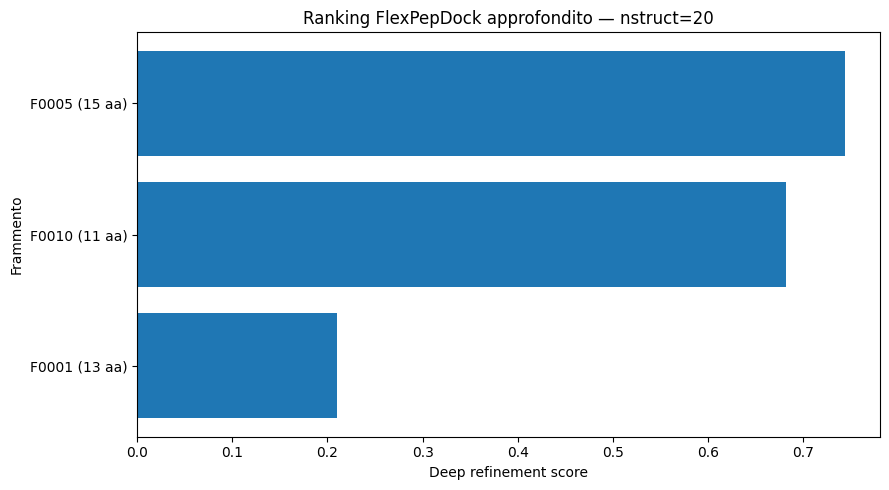

In [22]:
plot_df = deep_ranking.sort_values(
    "deep_refinement_score",
    ascending=True,
)

plt.figure(figsize=(9, 5))
plt.barh(
    plot_df["fragment_id"]
    + " ("
    + plot_df["length"].astype(str)
    + " aa)",
    plot_df["deep_refinement_score"],
)
plt.xlabel("Deep refinement score")
plt.ylabel("Frammento")
plt.title("Ranking FlexPepDock approfondito — nstruct=20")
plt.tight_layout()
plt.savefig(
    DEEP_DIR / "n20_deep_refinement_ranking.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

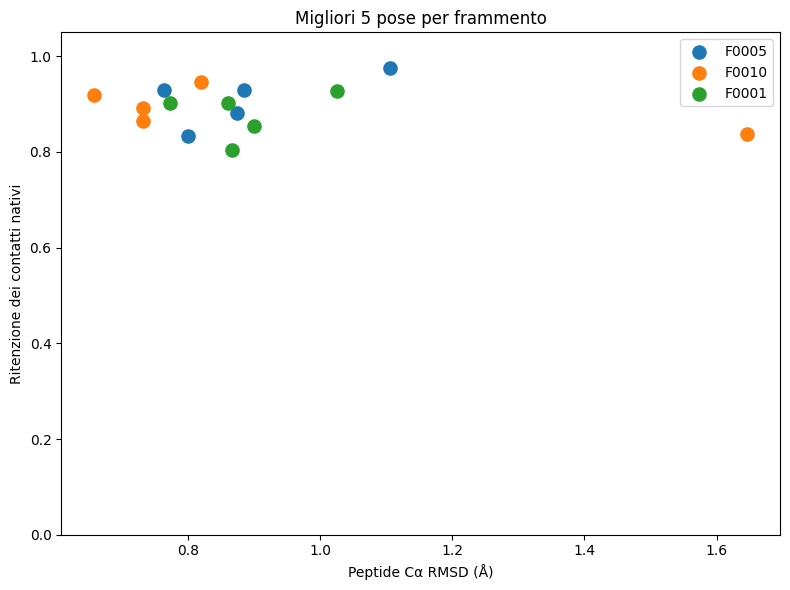

In [23]:
plt.figure(figsize=(8, 6))

for fragment_id in LEAD_FRAGMENT_IDS:
    subset = top5_evaluation[
        top5_evaluation["fragment_id"] == fragment_id
    ]

    plt.scatter(
        subset["peptide_CA_RMSD_A"],
        subset["native_contact_recall"],
        s=90,
        label=fragment_id,
    )

plt.xlabel("Peptide Cα RMSD (Å)")
plt.ylabel("Ritenzione dei contatti nativi")
plt.title("Migliori 5 pose per frammento")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(
    DEEP_DIR / "n20_top5_rmsd_vs_contact_recall.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 21. Esportazione


In [24]:
INPUT_VALIDATION_CSV = DEEP_DIR / "top3_input_validation.csv"
EXECUTION_STATUS_CSV = DEEP_DIR / "rosetta_execution_status.csv"
FINAL_STATUS_CSV = DEEP_DIR / "rosetta_final_output_status.csv"
ALL_SCORES_CSV = DEEP_DIR / "rosetta_n20_all_scores.csv"
SCORE_SUMMARY_CSV = DEEP_DIR / "rosetta_n20_score_summary.csv"
TOP5_SCORES_CSV = DEEP_DIR / "rosetta_n20_top5_scores.csv"
TOP5_EVALUATION_CSV = DEEP_DIR / "rosetta_n20_top5_structural_evaluation.csv"
STRUCTURAL_SUMMARY_CSV = DEEP_DIR / "rosetta_n20_structural_summary.csv"
BEST_POSES_CSV = DEEP_DIR / "rosetta_n20_best_pose_per_fragment.csv"
FINAL_RANKING_CSV = DEEP_DIR / "top3_deep_refinement_final_ranking.csv"
METADATA_JSON = DEEP_DIR / "top3_deep_refinement_metadata.json"

input_validation.to_csv(INPUT_VALIDATION_CSV, index=False)
execution_status.to_csv(EXECUTION_STATUS_CSV, index=False)
final_status.to_csv(FINAL_STATUS_CSV, index=False)
all_scores.to_csv(ALL_SCORES_CSV, index=False)
score_summary.to_csv(SCORE_SUMMARY_CSV, index=False)
top5_scores.to_csv(TOP5_SCORES_CSV, index=False)
top5_evaluation.to_csv(TOP5_EVALUATION_CSV, index=False)
structural_summary.to_csv(STRUCTURAL_SUMMARY_CSV, index=False)
best_pose_rows.to_csv(BEST_POSES_CSV, index=False)
deep_ranking.to_csv(FINAL_RANKING_CSV, index=False)

metadata = {
    "lead_fragment_ids": LEAD_FRAGMENT_IDS,
    "sequences": EXPECTED_SEQUENCES,
    "lengths": EXPECTED_LENGTHS,
    "rosetta_nstruct": ROSETTA_NSTRUCT,
    "expected_total_poses": (
        len(LEAD_FRAGMENT_IDS) * ROSETTA_NSTRUCT
    ),
    "actual_total_pdb_poses": total_pose_count,
    "primary_score_column": PRIMARY_SCORE_COLUMN,
    "rosetta_executable": rosetta_bin,
    "rosetta_database": str(rosetta_db),
    "contact_cutoff_A": CONTACT_CUTOFF_A,
    "clash_cutoff_A": CLASH_CUTOFF_A,
    "resume_policy": {
        "skip_completed_fragments": SKIP_COMPLETED_FRAGMENTS,
        "backup_incomplete_outputs": BACKUP_INCOMPLETE_OUTPUTS,
    },
    "interpretation_warning": (
        "The protocol is a near-native FlexPepDock refinement. "
        "Twenty poses improve local sampling but do not demonstrate "
        "blind docking, experimental affinity, autonomous folding, "
        "or inhibitory activity."
    ),
}

METADATA_JSON.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

for path in [
    INPUT_VALIDATION_CSV,
    EXECUTION_STATUS_CSV,
    FINAL_STATUS_CSV,
    ALL_SCORES_CSV,
    SCORE_SUMMARY_CSV,
    TOP5_SCORES_CSV,
    TOP5_EVALUATION_CSV,
    STRUCTURAL_SUMMARY_CSV,
    BEST_POSES_CSV,
    FINAL_RANKING_CSV,
    METADATA_JSON,
]:
    print("Salvato:", path.resolve())

print("Migliori pose:", BEST_POSE_DIR.resolve())
print("Top-5 pose allineate:", TOP_POSES_DIR.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/top3_input_validation.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta_execution_status.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta_final_output_status.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta_n20_all_scores.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta_n20_score_summary.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta_n20_top5_scores.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta_n20_top5_structural_evaluation.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/rosetta_n20_structural_summary.csv
Salvato: /Users/robertobruzzes

## 22. Report automatico


In [25]:
best = deep_ranking.iloc[0]

report = f'''# 03d — Top-3 FlexPepDock deep-refinement report

## Protocollo
- Frammenti: {", ".join(LEAD_FRAGMENT_IDS)}
- Pose richieste per frammento: {ROSETTA_NSTRUCT}
- Pose totali attese: {len(LEAD_FRAGMENT_IDS) * ROSETTA_NSTRUCT}
- Pose PDB trovate: {total_pose_count}
- Score principale: {PRIMARY_SCORE_COLUMN}

## Miglior frammento
- Fragment ID: {best["fragment_id"]}
- Sequenza: `{best["sequence"]}`
- Lunghezza: {int(best["length"])} aa
- Deep-refinement score: {best["deep_refinement_score"]:.4f}
- Miglior score Rosetta: {best["score_best"]:.4f}
- Media migliori 5 score: {best["score_top5_mean"]:.4f}
- Mediana delle pose: {best["score_median"]:.4f}
- RMSD medio top-5: {best["top5_peptide_RMSD_mean_A"]:.4f} Å
- Ritenzione media contatti top-5: {best["top5_native_contact_recall_mean"]:.4f}
- Conservazione media hotspot top-5: {best["top5_hotspot_preservation_mean"]:.4f}

## Interpretazione
Il ranking approfondito considera la distribuzione delle 20 pose e la stabilità strutturale delle migliori cinque pose. È quindi più robusto del ranking preliminare nstruct=2.

Il protocollo resta un refinement guidato da una posa quasi nativa. Non dimostra affinità sperimentale, docking cieco o attività inibitoria.
'''

REPORT_PATH = DEEP_DIR / "03d_top3_deep_refinement_report.md"
REPORT_PATH.write_text(report, encoding="utf-8")

print(report)
print("Report salvato:", REPORT_PATH.resolve())

# 03d — Top-3 FlexPepDock deep-refinement report

## Protocollo
- Frammenti: F0005, F0010, F0001
- Pose richieste per frammento: 20
- Pose totali attese: 60
- Pose PDB trovate: 60
- Score principale: reweighted_sc

## Miglior frammento
- Fragment ID: F0005
- Sequenza: `GYIGERCQYRDLKWW`
- Lunghezza: 15 aa
- Deep-refinement score: 0.7434
- Miglior score Rosetta: 9.0080
- Media migliori 5 score: 25.7108
- Mediana delle pose: 57.2060
- RMSD medio top-5: 0.8850 Å
- Ritenzione media contatti top-5: 0.9095
- Conservazione media hotspot top-5: 1.0000

## Interpretazione
Il ranking approfondito considera la distribuzione delle 20 pose e la stabilità strutturale delle migliori cinque pose. È quindi più robusto del ranking preliminare nstruct=2.

Il protocollo resta un refinement guidato da una posa quasi nativa. Non dimostra affinità sperimentale, docking cieco o attività inibitoria.

Report salvato: /Users/robertobruzzese/Desktop/venv/outputs/top3_flexpepdock_deep_refinement_03d/03d_top3_deep_r

## 23. Passaggio successivo

Dopo questa esecuzione si potrà decidere, sulla base della robustezza delle 20 pose:

- mantenere un lead principale e un riferimento più lungo;
- aumentare ulteriormente il campionamento soltanto sul miglior frammento;
- iniziare perturbazioni più ampie della posa;
- eseguire dinamica molecolare;
- generare varianti tramite diffusione;
- adattare CLEAR al peptide selezionato.

Non è necessario modificare il notebook 03c: il 03d costituisce un approfondimento separato e riproducibile.
